<a href="https://colab.research.google.com/github/SilkSherstka/hse_machine_learning/blob/main/Andronova_of_clustering_tutor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кластеризация: K-Means, DBSCAN, OPTICS

**Данные:** Wine Quality (`wineqr.csv`), 11 признаков, столбец `quality` не используется.

**Воспроизводимость:** `random_state=42` для K-Means; данные загружаются по URL (как в оригинальном Colab-туториале).


In [ ]:
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_URL = "https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/01.%20UCI/wineqr.csv"
DATA_PATH = Path("wineqr.csv")

if not DATA_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print("Saved:", DATA_PATH.resolve())
else:
    print("Using existing:", DATA_PATH.resolve())


Saved: /content/wineqr.csv


## Часть 1. Загрузка и предобработка

In [ ]:
df = pd.read_csv("wineqr.csv")
X = df.drop(columns=["quality"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X.shape, "samples,", X.shape[1], "features")


(1599, 11) samples, 11 features


## Часть 1. K-Means: локоть, силуэт, выбор K, PCA

In [ ]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")


K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


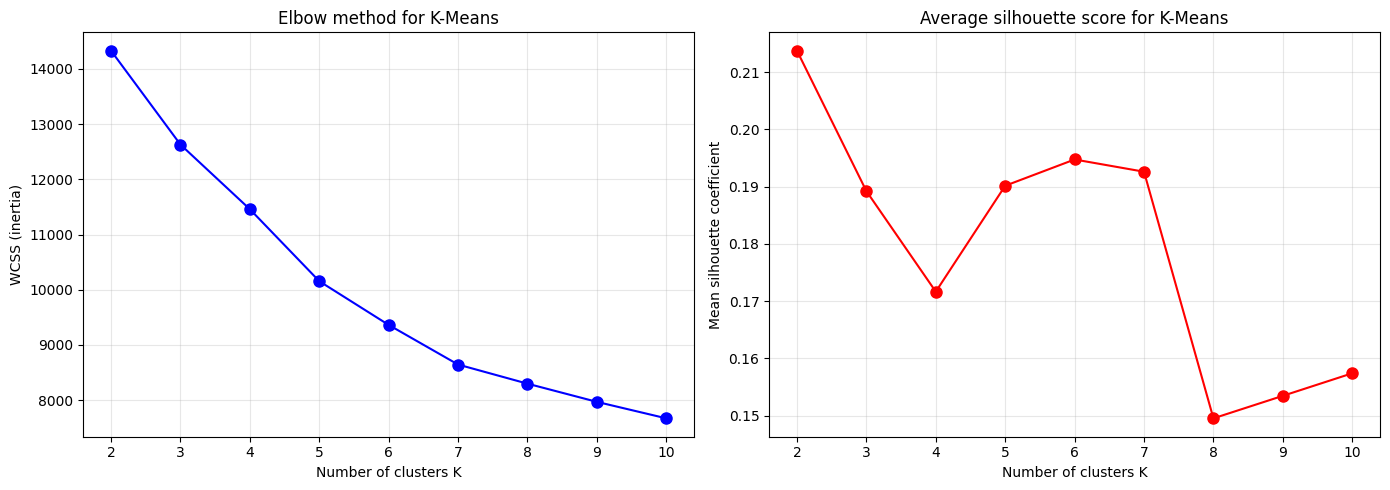

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(range_n_clusters), wcss, "bo-", markersize=8)
ax1.set_xlabel("Number of clusters K")
ax1.set_ylabel("WCSS (inertia)")
ax1.set_title("Elbow method for K-Means")
ax1.grid(True, alpha=0.3)

ax2.plot(list(range_n_clusters), silhouette_scores, "ro-", markersize=8)
ax2.set_xlabel("Number of clusters K")
ax2.set_ylabel("Mean silhouette coefficient")
ax2.set_title("Average silhouette score for K-Means")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
optimal_k = list(range_n_clusters)[int(np.argmax(silhouette_scores))]
print(f"Оптимальное K по силуэту: {optimal_k}")


Оптимальное K по силуэту: 2


In [ ]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
sil_kmeans_final = silhouette_score(X_scaled, kmeans_labels)
print(f"Силуэт финальной модели K-Means (K={optimal_k}): {sil_kmeans_final:.4f}")


Силуэт финальной модели K-Means (K=2): 0.2137


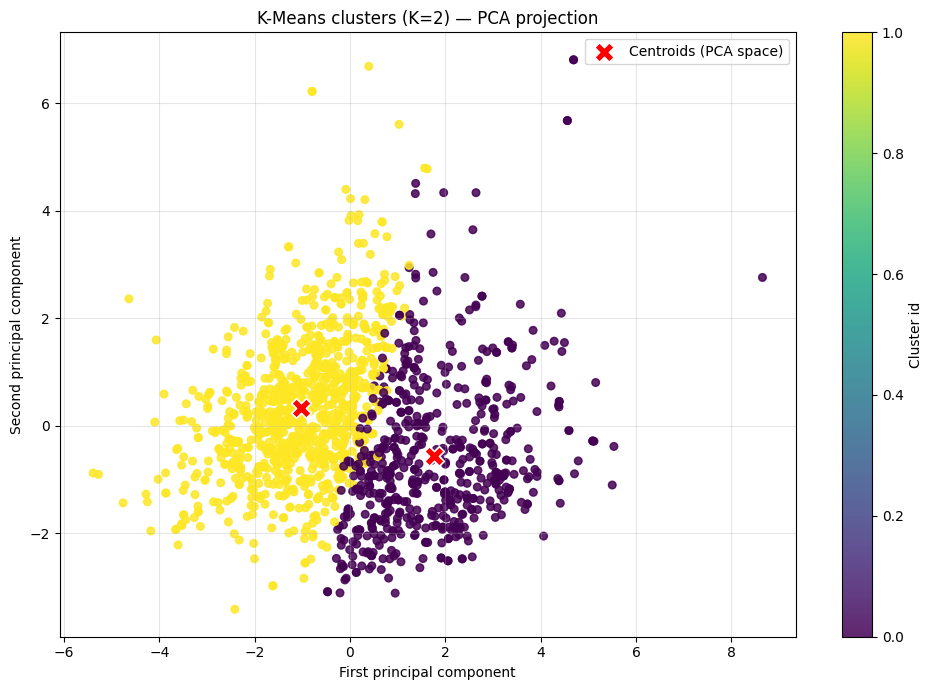

In [ ]:
pca_km = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_km = pca_km.fit_transform(X_scaled)
centers_pca = pca_km.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_pca_km[:, 0], X_pca_km[:, 1], c=kmeans_labels, cmap="viridis", s=30, alpha=0.85)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    c="red",
    s=200,
    label="Centroids (PCA space)",
    edgecolors="white",
    linewidths=1.2,
)
plt.title(f"K-Means clusters (K={optimal_k}) — PCA projection")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.colorbar(sc, label="Cluster id")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Часть 2. DBSCAN

Документация: [sklearn.cluster.DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

k-distance graph: для каждой точки — расстояние до `min_samples`-го соседа; сортировка по возрастанию (типичный подбор `eps`).

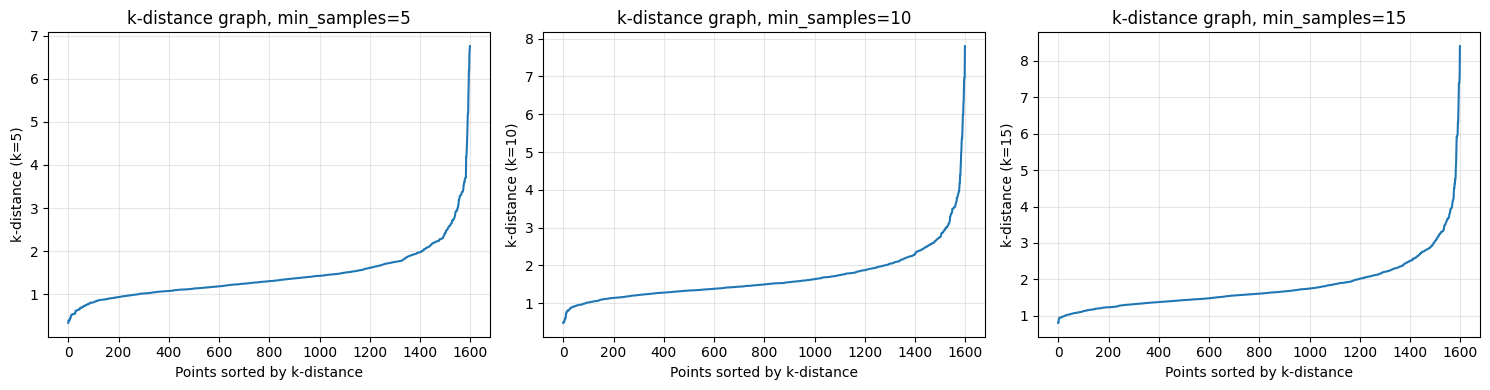

In [ ]:
def plot_k_distance(X, min_samples, ax=None):
    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X)
    dists, _ = neigh.kneighbors(X)
    k_dist = np.sort(dists[:, -1])
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(k_dist)
    ax.set_xlabel("Points sorted by k-distance")
    ax.set_ylabel(f"k-distance (k={min_samples})")
    ax.set_title(f"k-distance graph, min_samples={min_samples}")
    ax.grid(True, alpha=0.3)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ms in zip(axes, [5, 10, 15]):
    plot_k_distance(X_scaled, ms, ax=ax)
plt.tight_layout()
plt.show()


In [ ]:
def dbscan_silhouette(X, labels):
    mask = labels != -1
    if mask.sum() < 2:
        return None
    labs = labels[mask]
    if len(np.unique(labs)) < 2:
        return None
    return silhouette_score(X[mask], labs)


best = {"sil": -1.0, "eps": None, "min_samples": None, "labels": None}
noise_max_frac = 0.80

for min_samples in (5, 10, 15):
    for eps in np.arange(0.3, 1.15, 0.1):
        eps = round(float(eps), 1)
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_noise = (labels == -1).sum()
        if n_noise / len(labels) > noise_max_frac:
            continue
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clust < 2:
            continue
        sil = dbscan_silhouette(X_scaled, labels)
        if sil is None:
            continue
        if sil > best["sil"]:
            best = {"sil": sil, "eps": eps, "min_samples": min_samples, "labels": labels.copy()}

print("Лучшие параметры DBSCAN:", {k: v for k, v in best.items() if k != "labels"})


Лучшие параметры DBSCAN: {'sil': np.float64(0.24559029462188608), 'eps': 1.1, 'min_samples': 10}


In [ ]:
dbscan_best = DBSCAN(eps=best["eps"], min_samples=best["min_samples"])
dbscan_labels = dbscan_best.fit_predict(X_scaled)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = (dbscan_labels == -1).sum()
sil_db = dbscan_silhouette(X_scaled, dbscan_labels)
print(f"Кластеров: {n_clusters_db}, шум: {n_noise_db}, силуэт (без шума): {sil_db:.4f}")


Кластеров: 7, шум: 1234, силуэт (без шума): 0.2456


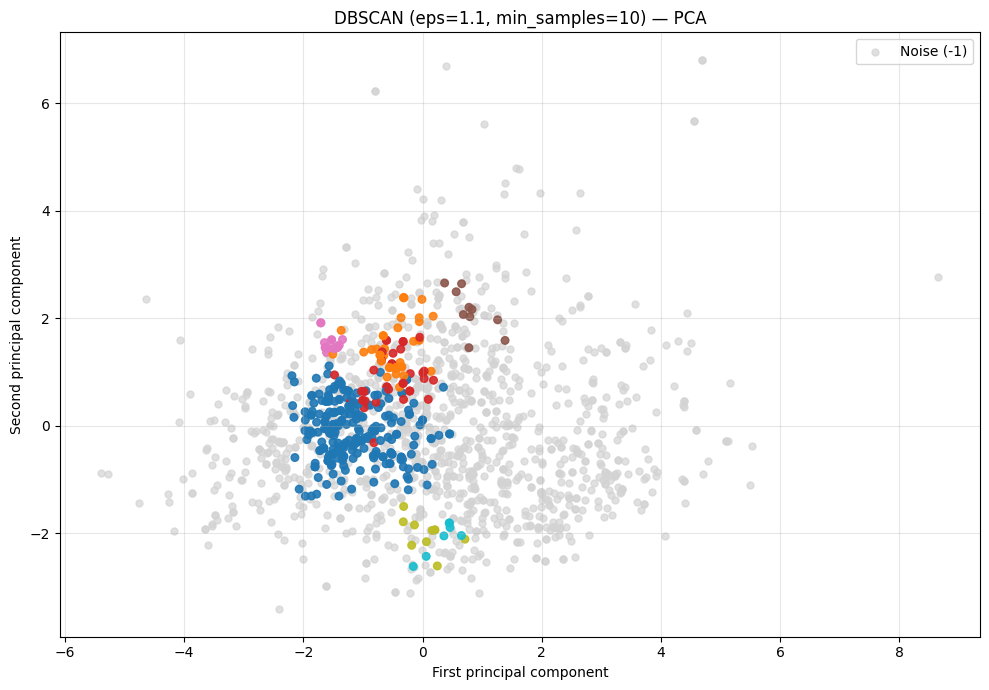

In [ ]:
pca_db = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_db = pca_db.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
noise_mask = dbscan_labels == -1
plt.scatter(
    X_pca_db[noise_mask, 0],
    X_pca_db[noise_mask, 1],
    c="lightgray",
    s=25,
    alpha=0.7,
    label="Noise (-1)",
)
plt.scatter(
    X_pca_db[~noise_mask, 0],
    X_pca_db[~noise_mask, 1],
    c=dbscan_labels[~noise_mask],
    cmap="tab10",
    s=30,
    alpha=0.9,
)
plt.title(f"DBSCAN (eps={best['eps']}, min_samples={best['min_samples']}) — PCA")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Ответы на вопросы (DBSCAN)

**Почему для DBSCAN критически важно масштабировать данные?**  
DBSCAN опирается на радиус eps в евклидовой метрике: признаки с большим масштабом и дисперсией «тянут» расстояние на себя, а признаки с малым масштабом почти не влияют. Без приведения шкал одно и то же численное значение eps соответствует разной «реальной» близости по разным осям, и плотные области искажаются. StandardScaler выравнивает вклад признаков.

**Что будет при слишком маленьком `eps`? Слишком большом?**  
Маленький eps: мало точек попадает в окрестность радиуса — много объектов объявляется шумом, кластеры дробятся или исчезают.  
Большой eps: соседние области сливаются, получается мало крупных кластеров или один гигантский кластер, граница «плотности» размывается.

**Что означают точки с меткой -1?**  
Это **шум** (outliers): точки, которые не попали ни в одну плотную область по правилам DBSCAN (не являются core/border в итоговой разметке).

**Чем DBSCAN принципиально отличается от K-Means по форме кластеров?**  
K-Means ищет **выпуклые** облака вокруг `K` центроидов (граница — кусочно-линейная в пространстве Вороного). DBSCAN находит **произвольной формы** связные плотные области и может отделить шум; число кластеров не задаётся заранее.


## Часть 3. OPTICS

Документация: [sklearn.cluster.OPTICS](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html)

Параметры: `min_samples=10`, `xi=0.05`, `min_cluster_size=0.05` (доля от числа объектов).


In [ ]:
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
optics_labels = optics.fit_predict(X_scaled)

n_clusters_opt = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
n_noise_opt = (optics_labels == -1).sum()
mask_o = optics_labels != -1
if mask_o.sum() >= 2 and len(np.unique(optics_labels[mask_o])) >= 2:
    sil_opt = silhouette_score(X_scaled[mask_o], optics_labels[mask_o])
else:
    sil_opt = float("nan")

print(f"Кластеров: {n_clusters_opt}")
print(f"Шумовых точек: {n_noise_opt}")
if np.isnan(sil_opt):
    print("Силуэт (без шума): не определён (нужно как минимум 2 кластера среди не-шумовых точек)")
else:
    print(f"Силуэт (без шума): {sil_opt:.4f}")


Кластеров: 1
Шумовых точек: 0
Силуэт (без шума): не определён (нужно как минимум 2 кластера среди не-шумовых точек)


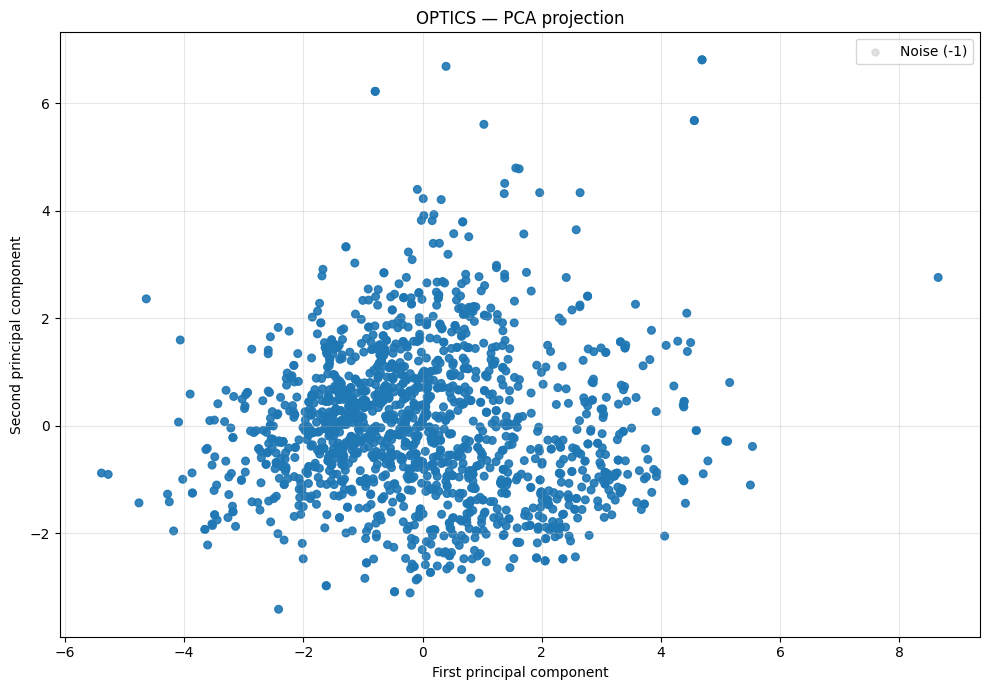

In [ ]:
pca_op = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_op = pca_op.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
nm = optics_labels == -1
plt.scatter(X_pca_op[nm, 0], X_pca_op[nm, 1], c="lightgray", s=25, alpha=0.7, label="Noise (-1)")
plt.scatter(
    X_pca_op[~nm, 0],
    X_pca_op[~nm, 1],
    c=optics_labels[~nm],
    cmap="tab10",
    s=30,
    alpha=0.9,
)
plt.title("OPTICS — PCA projection")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


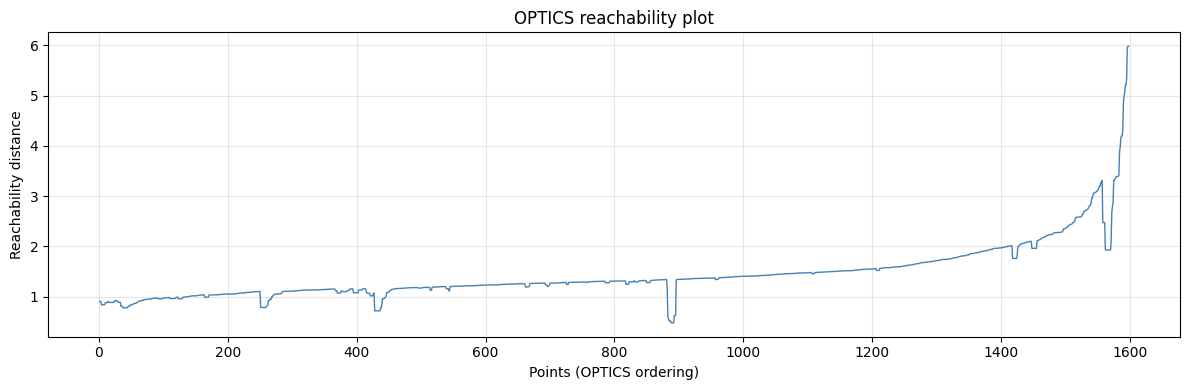

In [ ]:
reach = optics.reachability_[optics.ordering_]
space = np.arange(len(reach))

plt.figure(figsize=(12, 4))
plt.plot(space, reach, color="steelblue", linewidth=1)
plt.title("OPTICS reachability plot")
plt.xlabel("Points (OPTICS ordering)")
plt.ylabel("Reachability distance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Ответы на вопросы (OPTICS)

**Чем OPTICS отличается от DBSCAN? Два ключевых отличия.**  
1) OPTICS строит упорядочивание объектов и график достижимости, из которого можно выводить кластеры при разных «срезах» плотности, тогда как классический DBSCAN фиксирует одну пару (eps, min_samples).  
2) OPTICS лучше отражает иерархию плотности (вложенные/разной плотности структуры) за счёт хранения reachability-профиля, а не одного глобального порога eps для всех кластеров.

**Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?**  
xi задаёт относительный порог на углублении «ям» в reachability plot при извлечении Xi-кластеров: он определяет, насколько глубоким должен быть провал достижимости, чтобы считать границу между плотностными областями. Меньший xi — более «чувствительное» выделение границ (больше мелких сегментов), больший — более грубая сегментация.

**В каком случае OPTICS даст результат существенно лучше, чем DBSCAN? Пример.**  
Когда плотность кластеров сильно различается: например, один плотный шарик внутри разреженного облака и рядом ещё один кластер другой плотности. Фиксированный eps в DBSCAN либо сольёт разные плотности, либо «пробьёт» разреженную оболочку шумом; OPTICS по кривой достижимости видит разные плато и может извлечь оба уровня при настройке xi / min_cluster_size.

**Сравнение времени DBSCAN и OPTICS на этих данных.**  
См. ячейку ниже: одинаковые данные `X_scaled`, замер через `time.perf_counter()`.


In [1]:
t0 = time.perf_counter()
DBSCAN(eps=best["eps"], min_samples=best["min_samples"]).fit(X_scaled)
t_db = time.perf_counter() - t0

t0 = time.perf_counter()
OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05).fit(X_scaled)
t_op = time.perf_counter() - t0

print(f"DBSCAN (лучшие eps/min_samples): {t_db*1000:.2f} ms")
print(f"OPTICS (заданные параметры):      {t_op*1000:.2f} ms")


NameError: name 'time' is not defined

**Судя по визуализациям, какой алгоритм лучше разделил данные? Почему?**  

По численному силуэту на полной разметке K-Means обычно выигрывает на этом датасете, потому что силуэт формально измеряет компактность относительно центроидов, что совпадает с предположениями K-Means. Визуально в PCA картина может быть иной: если истинная структура невыпуклая или есть шум/выбросы, DBSCAN/OPTICS дают интерпретируемое разделение «плотное vs шум» и произвольные формы. Итоговый вывод стоит сопоставлять с графиками: при перекрывающихся облаках в 2D-проекции ни один метод не «доказывает» истину — PCA только визуализация 11-мерного пространства.
